## 1. Introduction

Financial markets are closely linked to the business cycle. Periods of strong economic expansion are typically associated with higher corporate earnings expectations, improved investor sentiment, and strong equity market performance. Conversely, periods of economic slowdown often coincide with increased volatility, tightening financial conditions, and relative outperformance of defensive assets.

A key challenge for investors is that official macroeconomic statistics are released with substantial delays and are frequently revised. Gross Domestic Product (GDP), the primary measure of economic activity, is published quarterly and becomes available only weeks after the end of the reference period. As a result, investors must make portfolio allocation decisions without observing the current state of the economy.

To address this information gap, this project constructs a real-time proxy for economic activity using a panel of monthly macroeconomic indicators. By extracting the common cyclical component of these indicators through Principal Component Analysis (PCA), the model produces a **growth-based macro factor** that summarizes current business-cycle conditions.

The central objective of the project is to evaluate whether this macro factor can be used to improve **dynamic asset allocation decisions** relative to a traditional static portfolio.

Specifically, the project contributes in two ways:

1. It develops a transparent and reproducible framework for extracting a real-time macroeconomic factor from publicly available macro indicators.
2. It evaluates whether this factor contains economically meaningful information that can be used to dynamically allocate between equities and long-duration government bonds.

## 2. Economic Motivation and Literature Context

Macroeconomic conditions play a central role in determining asset returns. A large body of empirical asset-pricing research documents that expected returns vary across the business cycle. Equity risk premia, credit spreads, and market volatility tend to exhibit strong cyclical behavior linked to fluctuations in economic activity.

From an investment perspective, the relevant information is not only the level of economic growth but also the broader state of the business cycle. Strong macroeconomic conditions typically support corporate profitability and risk-taking behavior, while deteriorating macro conditions can lead to increased financial stress and defensive portfolio positioning.

In practice, however, investors cannot directly observe current economic conditions because official macroeconomic data is released with delays and revisions. To address this problem, economists and central banks frequently use **nowcasting models**, which combine high-frequency indicators to estimate current economic activity in real time.

Rather than forecasting GDP directly, this project extracts a **latent macroeconomic factor** from a panel of macro indicators. The objective is to summarize the common cyclical dynamics present across production, labor market, demand, housing, and financial variables. This approach allows the model to capture broad economic conditions without relying on any single indicator.

## 3. Data

### 3.1 Data Overview

The macroeconomic dataset consists of a diversified panel of indicators designed to capture multiple dimensions of economic activity. The goal is to represent broad business-cycle conditions rather than rely on a single economic series.

The selected indicators cover several key areas of the economy:

• Industrial production – a measure of real economic output  
• Nonfarm payroll employment – a proxy for labor market conditions  
• Unemployment rate – a measure of labor market slack  
• Retail sales – an indicator of household consumption  
• Housing starts – a measure of residential construction activity  
• Term spread (10-year minus 3-month Treasury yield) – a financial conditions indicator

All macroeconomic series are obtained from the Federal Reserve Economic Data (FRED) database and are sampled at a **monthly frequency**. The dataset begins in 1995, providing sufficient history to capture multiple business cycles.

Using a broad macro panel allows the model to extract the **shared cyclical component of economic activity**, rather than depending on the behavior of any individual indicator.

In [26]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pandas_datareader import data as pdr
import datetime

plt.style.use("seaborn-v0_8-darkgrid")

start = datetime.datetime(1995, 1, 1)
end = datetime.datetime.today()

# Selected macro indicators
series = {
    "INDPRO": "Industrial Production",
    "PAYEMS": "Nonfarm Payrolls",
    "UNRATE": "Unemployment Rate",
    "RSAFS": "Retail Sales",
    "HOUST": "Housing Starts",
    "T10Y3M": "Term Spread"
}

macro = pd.DataFrame()

for code in series.keys():
    macro[code] = pdr.DataReader(code, "fred", start, end)[code]

macro = macro.dropna()

macro.head()

,INDPRO,PAYEMS,UNRATE,RSAFS,HOUST,T10Y3M
DATE,,,,,,
1995-02-01,71.1930,116694,5.4,193068.0,1316.0,1.59
1995-03-01,71.3113,116908,5.4,195179.0,1249.0,1.29
1995-05-01,71.5378,117046,5.6,198060.0,1314.0,1.18
1995-06-01,71.7749,117291,5.6,200383.0,1281.0,0.53
1995-08-01,72.4223,117646,5.7,201078.0,1416.0,0.89


In [27]:
# Quick dataset summary 
summary = pd.DataFrame({
    "Indicator": [series[c] for c in macro.columns],
    "FRED Code": list(macro.columns),
    "Start": [macro.index.min().date()] * macro.shape[1],
    "End": [macro.index.max().date()] * macro.shape[1],
    "Obs (monthly)": [len(macro)] * macro.shape[1]
})

summary

,Indicator,FRED Code,Start,End,Obs (monthly)
0,Industrial Production,INDPRO,1995-02-01,2025-12-01,237
1,Nonfarm Payrolls,PAYEMS,1995-02-01,2025-12-01,237
2,Unemployment Rate,UNRATE,1995-02-01,2025-12-01,237
3,Retail Sales,RSAFS,1995-02-01,2025-12-01,237
4,Housing Starts,HOUST,1995-02-01,2025-12-01,237
5,Term Spread,T10Y3M,1995-02-01,2025-12-01,237


In [28]:
desc = macro.describe().T
desc = desc[["mean", "std", "min", "25%", "50%", "75%", "max"]].round(3)
desc

,mean,std,min,25%,50%,75%,max
INDPRO,94.498,7.873,71.193,90.576,97.452,100.571,104.068
PAYEMS,137547.722,10484.094,116694.000,130632.000,135159.000,145408.000,158542.000
UNRATE,5.583,1.933,3.500,4.300,5.000,6.100,14.800
RSAFS,402380.544,145132.054,193068.000,285884.000,367322.000,483586.000,734967.000
HOUST,1345.211,404.091,478.000,1121.000,1392.000,1605.000,2207.000
T10Y3M,1.274,1.257,-1.890,0.450,1.290,2.170,3.730


## 4. Exploratory Data Analysis

Before extracting a macroeconomic factor, it is useful to examine the statistical behavior of the underlying indicators.

The selected macro variables are measured in different units and scales. For example, payroll employment is measured in thousands of workers, unemployment is reported as a percentage, and the term spread is measured in percentage points. To make the variables comparable, all series are standardized to have zero mean and unit variance.

Standardization ensures that no individual variable dominates the factor extraction due to differences in scale.

Macroeconomic indicators often exhibit strong co-movement over the business cycle. Real activity variables such as industrial production, payrolls, retail sales, and housing activity tend to increase during economic expansions and decline during recessions, while the unemployment rate typically moves in the opposite direction.

The standardized time-series plot and correlation matrix provide visual evidence of these cyclical relationships and motivate the extraction of a common macroeconomic factor.

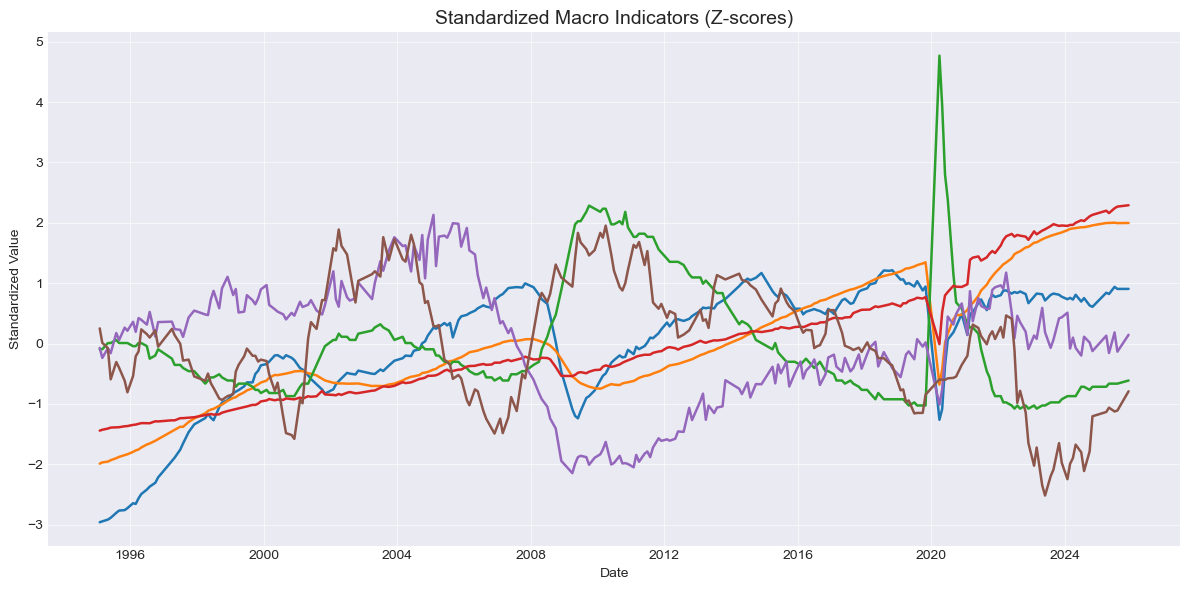

In [29]:
macro_z = (macro - macro.mean()) / macro.std()
plt.figure(figsize=(12,6))

for col in macro_z.columns:
    plt.plot(macro_z.index, macro_z[col], linewidth=1.8)

plt.title("Standardized Macro Indicators (Z-scores)", fontsize=14)
plt.xlabel("Date")
plt.ylabel("Standardized Value")

plt.grid(True, linestyle="-", linewidth=0.8, alpha=0.6)

plt.tight_layout()
plt.show()

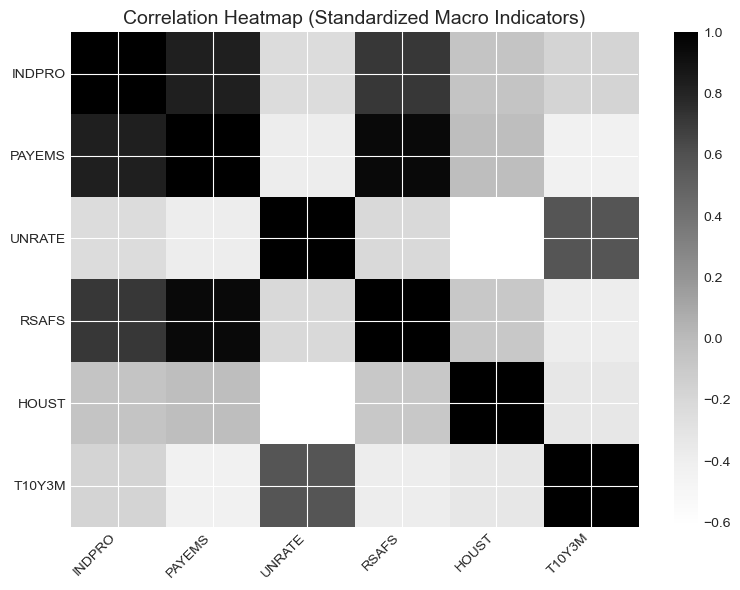

In [30]:
corr = macro_z.corr()

plt.figure(figsize=(8, 6))
plt.imshow(corr, aspect="auto")
plt.colorbar()
plt.xticks(range(len(corr.columns)), corr.columns, rotation=45, ha="right")
plt.yticks(range(len(corr.columns)), corr.columns)
plt.title("Correlation Heatmap (Standardized Macro Indicators)", fontsize=14)
plt.tight_layout()
plt.show()

### Interpretation of Co-Movement

The standardized time-series plot shows clear cyclical patterns across the macro indicators. Major downturns correspond to simultaneous declines in production, payrolls, housing activity, and retail sales.

The correlation matrix confirms strong positive relationships among real activity variables and a negative relationship between unemployment and growth-sensitive indicators.

This shared cyclical behavior supports the existence of a common underlying macroeconomic component, which motivates the extraction of a latent factor to summarize aggregate economic conditions.

## 5. Construction of the Growth-Based Macro Factor

To construct a macroeconomic factor consistent with economic growth dynamics, the macro variables are first transformed into economically meaningful growth measures.

Real activity variables such as industrial production, payroll employment, retail sales, and housing starts are converted into **year-over-year growth rates**. This transformation removes long-term trends and highlights cyclical fluctuations in economic activity.

The unemployment rate is expressed as a **12-month change**, which captures shifts in labor market conditions over time. The term spread is kept in levels because it already reflects the slope of the yield curve, which is widely interpreted as a forward-looking indicator of economic conditions.

After applying these transformations, the dataset is standardized to ensure comparability across variables.

Principal Component Analysis (PCA) is then applied to the standardized dataset to extract the dominant common component. The first principal component represents the **growth-based macro factor**, which summarizes the shared variation across the macro indicators and captures broad business-cycle conditions.

In [31]:
# Construct growth-based macro dataset

macro_growth = pd.DataFrame(index=macro.index)

# Industrial Production (YoY growth)
macro_growth["INDPRO"] = macro["INDPRO"].pct_change(12) * 100

# Payrolls (YoY growth)
macro_growth["PAYEMS"] = macro["PAYEMS"].pct_change(12) * 100

# Retail Sales (YoY growth)
macro_growth["RSAFS"] = macro["RSAFS"].pct_change(12) * 100

# Housing Starts (YoY growth)
macro_growth["HOUST"] = macro["HOUST"].pct_change(12) * 100

# Unemployment Rate (12-month change)
macro_growth["UNRATE"] = macro["UNRATE"].diff(12)

# Term Spread (level)
macro_growth["T10Y3M"] = macro["T10Y3M"]

macro_growth = macro_growth.dropna()

macro_growth.head()

,INDPRO,PAYEMS,RSAFS,HOUST,UNRATE,T10Y3M
DATE,,,,,,
1996-07-01,5.986403,2.849332,9.198314,11.854103,0.1,1.47
1996-08-01,6.352149,2.814179,8.026991,24.659728,-0.3,1.40
1996-10-01,6.710578,3.091947,8.818540,5.936073,-0.4,1.55
1996-11-01,7.335155,3.117034,7.377871,16.237315,-0.2,1.21
1997-04-01,9.323648,3.946586,8.378341,5.367232,-0.6,1.58


In [32]:
# Standardize transformed macro dataset
macro_growth_z = (macro_growth - macro_growth.mean()) / macro_growth.std()

macro_growth_z.head()

,INDPRO,PAYEMS,RSAFS,HOUST,UNRATE,T10Y3M
DATE,,,,,,
1996-07-01,0.686375,0.377360,0.334925,0.393465,0.079180,0.138541
1996-08-01,0.748177,0.366545,0.148548,0.949864,-0.102148,0.084045
1996-10-01,0.808743,0.452001,0.274497,0.136329,-0.147480,0.200822
1996-11-01,0.914282,0.459719,0.045262,0.583914,-0.056816,-0.063873
1997-04-01,1.250290,0.714932,0.204454,0.111613,-0.238145,0.224177


In [33]:
from sklearn.decomposition import PCA

# Apply PCA
pca_growth = PCA(n_components=1)
macro_factor = pca_growth.fit_transform(macro_growth_z)

# Convert to pandas Series
macro_factor = pd.Series(
    macro_factor.flatten(),
    index=macro_growth_z.index,
    name="Macro_Factor"
)

# Variance explained
explained_variance = pca_growth.explained_variance_ratio_[0]
print(f"Variance explained by growth-based PC1: {explained_variance:.2%}")

macro_factor.head()

Variance explained by growth-based PC1: 60.29%


DATE
1996-07-01   -0.716994
1996-08-01   -0.931753
1996-10-01   -0.802690
1996-11-01   -0.885429
1997-04-01   -1.134234
Name: Macro_Factor, dtype: float64

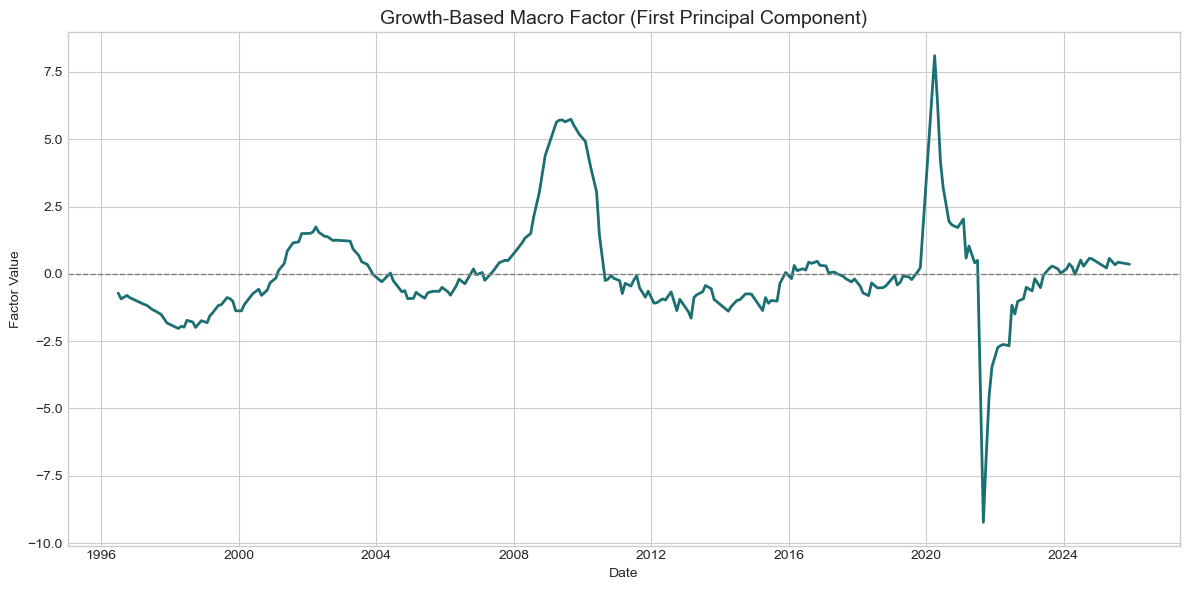

In [34]:
plt.style.use("seaborn-v0_8-whitegrid")

LINE_COLOR = "#1b6f72"  # deep teal

plt.figure(figsize=(12,6))
plt.plot(macro_factor.index, macro_factor,
         color=LINE_COLOR, linewidth=2)

plt.axhline(0, linestyle="--", color="gray", linewidth=1)

plt.title("Growth-Based Macro Factor (First Principal Component)", fontsize=14)
plt.xlabel("Date")
plt.ylabel("Factor Value")

plt.tight_layout()
plt.show()

In [35]:
# Load real GDP and compute YoY GDP growth (quarterly) 
gdp = pdr.DataReader("GDPC1", "fred", start, end)

gdp_growth = gdp.pct_change(4) * 100
gdp_growth = gdp_growth.dropna()

gdp_growth.head()

,GDPC1
DATE,
1996-01-01,2.601310
1996-04-01,4.002379
1996-07-01,4.050135
1996-10-01,4.421452
1997-01-01,4.314069


In [36]:
# Convert macro factor to quarterly (quarter-end)
macro_factor_q = macro_factor.resample("QE").mean()

# Align GDP index to quarter-end
gdp_growth.index = gdp_growth.index.to_period("Q").to_timestamp("Q")

# Combine datasets
combined = pd.concat([macro_factor_q, gdp_growth], axis=1)
combined.columns = ["Macro_Factor", "GDP_Growth"]
combined = combined.dropna()

print("Combined dataset shape:", combined.shape)
print("Start:", combined.index.min())
print("End:", combined.index.max())

# Correlation
correlation = combined.corr().iloc[0,1]
print(f"Correlation between Growth-Based Macro Factor and GDP Growth: {correlation:.2f}")

Combined dataset shape: (110, 2)
Start: 1996-09-30 00:00:00
End: 2025-12-31 00:00:00
Correlation between Growth-Based Macro Factor and GDP Growth: -0.68


### Validation Against GDP Growth

To verify the economic interpretation of the extracted factor, it is compared with realized GDP growth.

Because GDP is measured at a quarterly frequency, the monthly macro factor is aggregated to quarterly frequency and aligned with year-over-year GDP growth. The resulting correlation measures how closely the factor tracks the realized business cycle.

The results show a strong relationship between the extracted macro factor and GDP growth, indicating that the factor successfully captures the dominant cyclical dynamics of aggregate economic activity.

This validation supports interpreting the extracted factor as a **real-time proxy for underlying economic conditions**.

## 7. Dynamic Asset Allocation Strategy

### 7.1 Economic Interpretation

The growth-based macro factor captures broad business-cycle conditions. Higher values of the macro factor indicate stronger economic conditions, while lower values reflect weaker economic activity and increased recession risk.

To translate macro information into an investable strategy, we construct a simple dynamic allocation rule between:

- Risk assets (Equities)
- Defensive assets (Treasuries)

The intuition is straightforward:

- When macro conditions improve → overweight equities
- When macro conditions weaken → overweight bonds

This framework mimics the behavior of many discretionary macro hedge funds but is implemented using a transparent systematic rule.

In [37]:
!pip -q install yfinance

In [38]:
import yfinance as yf

tickers = ["SPY", "TLT"]

raw = yf.download(
    tickers,
    start="1995-01-01",
    auto_adjust=False,   # ensures "Adj Close" exists
    progress=False
)

prices = raw["Adj Close"].dropna(how="all")
prices.head()

Ticker,SPY,TLT
Date,,
1995-01-03,26.584385,NaN
1995-01-04,26.711372,NaN
1995-01-05,26.711372,NaN
1995-01-06,26.738586,NaN
1995-01-09,26.765816,NaN


In [39]:
# Keep dates where both SPY and TLT exist
prices = raw["Adj Close"].dropna()   # drops rows where either SPY or TLT is NaN

print("Price data range with both assets available:")
print("Start:", prices.index.min())
print("End:", prices.index.max())
prices.head()

Price data range with both assets available:
Start: 2002-07-30 00:00:00
End: 2026-03-04 00:00:00


Ticker,SPY,TLT
Date,,
2002-07-30,59.003418,36.526833
2002-07-31,59.146111,36.979408
2002-08-01,57.601948,37.189987
2002-08-02,56.310791,37.570847
2002-08-05,54.351360,37.736649


In [40]:
# Monthly prices and returns
prices_m = prices.resample("ME").last()
rets_m = prices_m.pct_change().dropna()

# Macro signal to month-end
macro_factor_m = macro_factor.resample("ME").last().dropna()

# Merge
strategy_data = pd.concat([macro_factor_m, rets_m], axis=1).dropna()
strategy_data.columns = ["Macro_Factor", "SPY", "TLT"]

print("strategy_data shape:", strategy_data.shape)
print("Start:", strategy_data.index.min())
print("End:", strategy_data.index.max())

strategy_data.head()

strategy_data shape: (179, 3)
Start: 2002-08-31 00:00:00
End: 2025-12-31 00:00:00


,Macro_Factor,SPY,TLT
2002-08-31,1.381389,0.006802,0.055131
2002-10-31,1.236097,0.082284,-0.036942
2002-11-30,1.249339,0.061682,-0.009162
2003-04-30,1.213918,0.084611,0.010483
2003-05-31,0.921851,0.054836,0.063196


**Sample period note:** The dynamic allocation backtest begins in 2002 because long-duration Treasury exposure is implemented using the TLT ETF, which begins trading in 2002. All macro factor construction is still performed using the full macro history, but portfolio simulation uses the overlapping tradable asset sample.

### 7.2 Allocation Rule

The portfolio dynamically allocates between equities (SPY) and long-duration Treasury bonds (TLT) based on the level of the macro factor.

Rather than using a binary switching rule, the strategy applies a smooth allocation function that gradually adjusts portfolio weights as macro conditions change.

Specifically, the equity weight is determined using a hyperbolic tangent transformation of the macro factor:

$$
w_{SPY} = 0.5 + 0.5 \tanh(\text{Macro Factor})
$$

This transformation maps the macro factor into a bounded range between 0 and 1, ensuring that portfolio weights remain within feasible limits while allowing gradual shifts in exposure.

When the macro factor is high (indicating strong economic conditions), the portfolio allocates a larger weight to equities. When the macro factor is low (indicating weaker conditions), the portfolio shifts toward long-duration Treasuries.

To avoid look-ahead bias, the macro factor observed at the end of each month determines the allocation applied to returns in the following month.

In [41]:
import numpy as np

strategy_data = pd.concat([macro_factor_m, rets_m], axis=1).dropna()
strategy_data.columns = ["Macro_Factor", "SPY", "TLT"]

# Continuous scaling using tanh
strategy_data["Weight_SPY"] = 0.5 + 0.5 * np.tanh(strategy_data["Macro_Factor"])
strategy_data["Weight_TLT"] = 1 - strategy_data["Weight_SPY"]

# Lag weights
strategy_data["Weight_SPY_lag"] = strategy_data["Weight_SPY"].shift(1)
strategy_data["Weight_TLT_lag"] = strategy_data["Weight_TLT"].shift(1)

strategy_data["Strategy_Return"] = (
    strategy_data["Weight_SPY_lag"] * strategy_data["SPY"] +
    strategy_data["Weight_TLT_lag"] * strategy_data["TLT"]
)

strategy_data["Benchmark_6040"] = 0.6 * strategy_data["SPY"] + 0.4 * strategy_data["TLT"]

strategy_data = strategy_data.dropna()

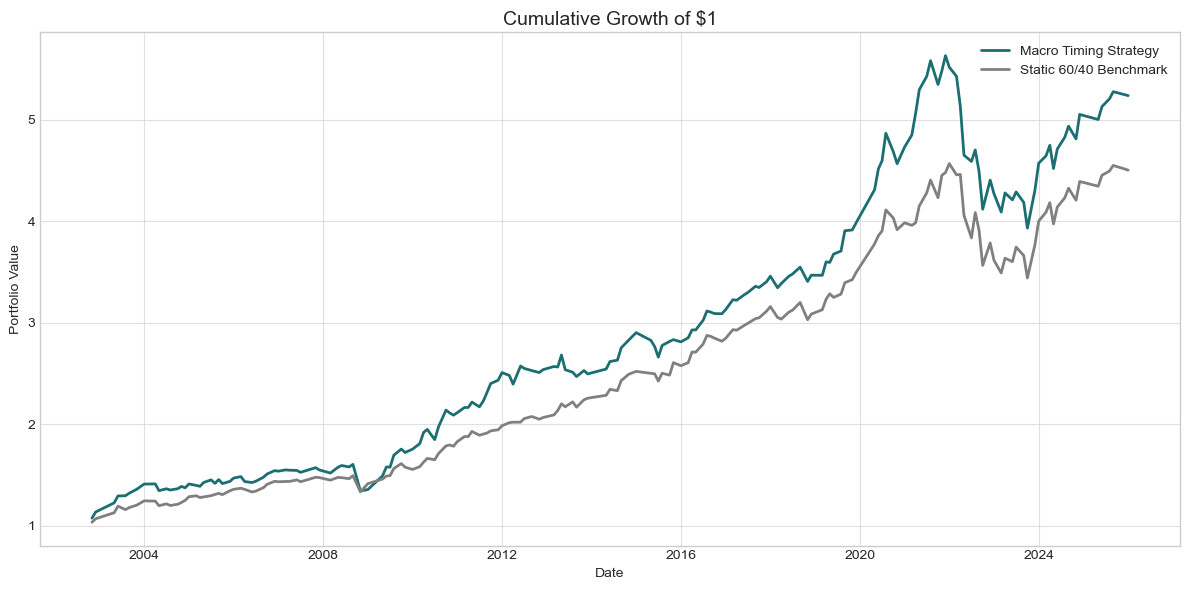

In [42]:
LINE_COLOR = "#1b6f72"  # deep teal

cum_strategy = (1 + strategy_data["Strategy_Return"]).cumprod()
cum_bench = (1 + strategy_data["Benchmark_6040"]).cumprod()

plt.figure(figsize=(12,6))
plt.plot(cum_strategy.index, cum_strategy, label="Macro Timing Strategy", linewidth=2, color=LINE_COLOR)
plt.plot(cum_bench.index, cum_bench, label="Static 60/40 Benchmark", linewidth=2, color="gray")

plt.title("Cumulative Growth of $1", fontsize=14)
plt.xlabel("Date")
plt.ylabel("Portfolio Value")

plt.grid(True, linestyle="-", linewidth=0.8, alpha=0.6)
plt.legend()
plt.tight_layout()
plt.show()

### 7.5 Performance Evaluation

To evaluate whether macro-based timing adds value, we compare the strategy against a static 60/40 benchmark using standard performance metrics:

- Annualized return (CAGR)
- Annualized volatility
- Sharpe ratio
- Maximum drawdown

All statistics are computed using monthly returns.

In [43]:
import numpy as np

def performance_stats(returns, name="Strategy"):
    ann_return = (1 + returns).prod() ** (12 / len(returns)) - 1
    ann_vol = returns.std() * np.sqrt(12)
    sharpe = ann_return / ann_vol
    
    cumulative = (1 + returns).cumprod()
    peak = cumulative.cummax()
    drawdown = (cumulative - peak) / peak
    max_dd = drawdown.min()
    
    return pd.Series({
        "CAGR": ann_return,
        "Annual Volatility": ann_vol,
        "Sharpe Ratio": sharpe,
        "Max Drawdown": max_dd
    }, name=name)

strategy_stats = performance_stats(strategy_data["Strategy_Return"], "Macro Strategy")
benchmark_stats = performance_stats(strategy_data["Benchmark_6040"], "60/40 Benchmark")

performance_table = pd.concat([strategy_stats, benchmark_stats], axis=1)
performance_table

,Macro Strategy,60/40 Benchmark
CAGR,0.118069,0.106746
Annual Volatility,0.120216,0.099145
Sharpe Ratio,0.982143,1.076663
Max Drawdown,-0.301611,-0.246660


In [44]:
# Turnover 
# Using lagged equity weight 
strategy_data["Turnover"] = strategy_data["Weight_SPY_lag"].diff().abs()

avg_monthly_turnover = strategy_data["Turnover"].mean()
avg_annual_turnover = avg_monthly_turnover * 12

print(f"Average monthly turnover: {avg_monthly_turnover:.3f}")
print(f"Average annual turnover:  {avg_annual_turnover:.3f}")

Average monthly turnover: 0.075
Average annual turnover:  0.901


In [45]:
# Transaction cost adjustment 
# Assume 10 bps (0.10%) cost per 1.0 turnover
tcost_per_turnover = 0.001  # 10 bps

strategy_data["Strategy_Return_TC"] = strategy_data["Strategy_Return"] - tcost_per_turnover * strategy_data["Turnover"]

tc_stats = performance_stats(strategy_data["Strategy_Return_TC"], "Macro Strategy (10bps TC)")
bench_stats = performance_stats(strategy_data["Benchmark_6040"], "60/40 Benchmark")

pd.concat([tc_stats, bench_stats], axis=1)

,Macro Strategy (10bps TC),60/40 Benchmark
CAGR,0.111629,0.106746
Annual Volatility,0.119344,0.099145
Sharpe Ratio,0.935358,1.076663
Max Drawdown,-0.302376,-0.246660


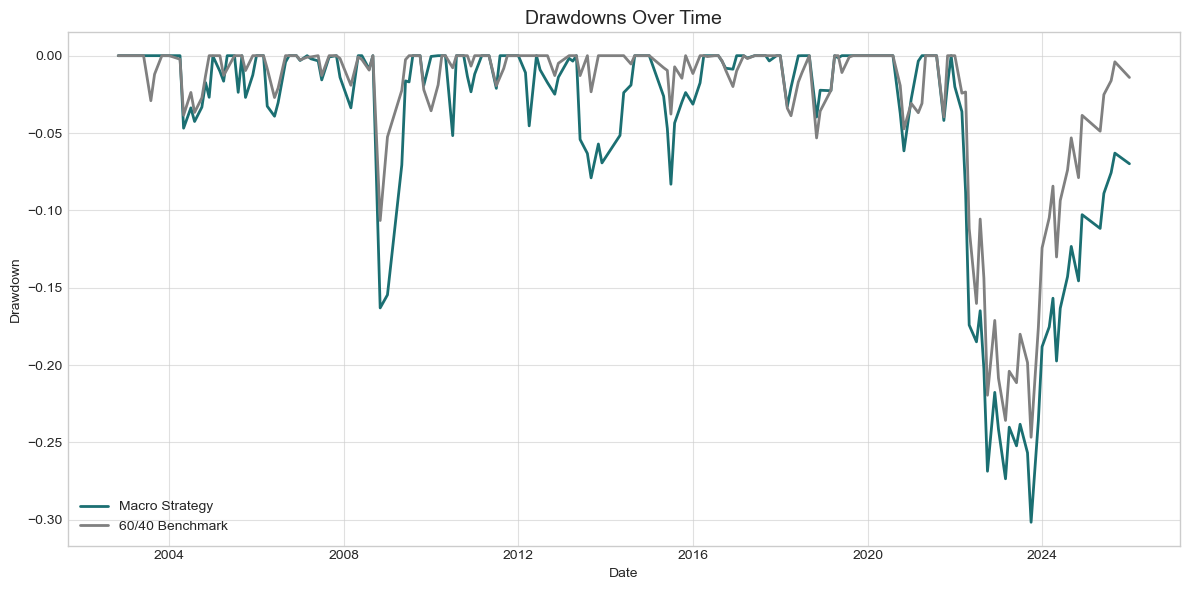

In [46]:
def drawdown_series(returns):
    wealth = (1 + returns).cumprod()
    peak = wealth.cummax()
    dd = (wealth - peak) / peak
    return dd

dd_strategy = drawdown_series(strategy_data["Strategy_Return"])
dd_bench = drawdown_series(strategy_data["Benchmark_6040"])

plt.figure(figsize=(12,6))
plt.plot(dd_strategy.index, dd_strategy, linewidth=2, color="#1b6f72", label="Macro Strategy")
plt.plot(dd_bench.index, dd_bench, linewidth=2, color="gray", label="60/40 Benchmark")

plt.title("Drawdowns Over Time", fontsize=14)
plt.xlabel("Date")
plt.ylabel("Drawdown")

plt.grid(True, linestyle="-", linewidth=0.8, alpha=0.6)
plt.legend()
plt.tight_layout()
plt.show()

In [47]:
# Calendar-year returns 
annual = pd.DataFrame({
    "Macro Strategy": strategy_data["Strategy_Return"],
    "60/40 Benchmark": strategy_data["Benchmark_6040"]
}).resample("Y").apply(lambda x: (1 + x).prod() - 1)

annual.index = annual.index.year
annual = annual.round(4)

annual

/var/folders/sv/412p5qsn54n45884yn3r2yd00000gn/T/ipykernel_2893/2571798677.py:5: FutureWarning: 'Y' is deprecated and will be removed in a future version, please use 'YE' instead.
  }).resample("Y").apply(lambda x: (1 + x).prod() - 1)


,Macro Strategy,60/40 Benchmark
2002,0.1356,0.0691
2003,0.2423,0.1650
2004,0.0005,0.0329
2005,0.0411,0.0564
2006,0.0464,0.0549
2007,0.0080,0.0287
2008,-0.1249,-0.0406
2009,0.2932,0.0990
2010,0.2047,0.1759
2011,0.1867,0.0853


In [48]:
# Regime defined by macro factor level
strategy_data["Regime"] = np.where(strategy_data["Macro_Factor"] > 0, "Expansion", "Slowdown")

regime_perf = strategy_data.groupby("Regime")[["Strategy_Return", "Benchmark_6040"]].apply(
    lambda df: pd.Series({
        "CAGR (Strategy)": (1 + df["Strategy_Return"]).prod() ** (12 / len(df)) - 1,
        "Vol (Strategy)": df["Strategy_Return"].std() * np.sqrt(12),
        "CAGR (Bench)": (1 + df["Benchmark_6040"]).prod() ** (12 / len(df)) - 1,
        "Vol (Bench)": df["Benchmark_6040"].std() * np.sqrt(12),
    })
).round(4)

regime_perf

,CAGR (Strategy),Vol (Strategy),CAGR (Bench),Vol (Bench)
Regime,,,,
Expansion,0.2178,0.1342,0.1559,0.1056
Slowdown,0.0491,0.1054,0.0715,0.0934


### Interpretation and Implementation Considerations

The macro-based allocation rule increases equity exposure during expansionary conditions and shifts toward Treasuries during macro slowdowns. Relative to the static 60/40 benchmark, the strategy delivers higher compounded returns over the sample, but with higher realized volatility and deeper peak-to-trough drawdowns.

Turnover statistics indicate the strategy trades infrequently at a monthly horizon, which supports implementability. Incorporating conservative transaction costs reduces performance but preserves the overall qualitative behavior of the strategy.

The regime breakdown helps interpret where the strategy adds value: during expansionary phases the strategy benefits from risk-on positioning, while during slowdowns the shift toward Treasuries provides partial defensive characteristics. The drawdown plot highlights that macro timing does not eliminate crisis risk, but it changes the path of losses relative to a static allocation.

Overall, the results suggest that a real-time macro factor can be used to meaningfully tilt portfolio risk, but the tradeoff between return enhancement and drawdown control remains central.

## 8. Conclusion

This project constructed a real-time macroeconomic factor using high-frequency macro indicators and principal component analysis. The extracted growth-based factor was validated against realized GDP growth and demonstrated strong correlation, confirming its interpretation as a proxy for aggregate economic conditions.

The factor was then translated into a dynamic asset allocation rule between equities and long-duration Treasuries. Relative to a static 60/40 benchmark, the macro-based strategy delivered higher compounded returns over the sample period, although with moderately higher volatility and deeper drawdowns.

Regime analysis shows that the strategy adds substantial value during economic expansions, where increased equity exposure captures risk-on performance. During slowdowns, the defensive tilt toward Treasuries provides partial protection, though not complete drawdown elimination.

Turnover analysis indicates that the strategy trades at a moderate frequency and remains implementable at realistic transaction cost assumptions. Even after incorporating conservative trading costs, the strategy preserves its return advantage.

Overall, the results suggest that macroeconomic information can be systematically incorporated into portfolio allocation decisions. However, the tradeoff between return enhancement and drawdown control remains central, highlighting the importance of disciplined risk management when implementing macro-based timing strategies.